In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os

patient_folder = "data/dataset/YG_0LCI9NV44UK0"  # replace with a real folder
flair_file = [f for f in os.listdir(patient_folder) if "_flair_img" in f][0]
mask_file = [f for f in os.listdir(patient_folder) if "_whole_seg" in f][0]

flair_path = os.path.join(patient_folder, flair_file)
mask_path = os.path.join(patient_folder, mask_file)

# load NIfTI images
flair_nii = nib.load(flair_path).get_fdata()
mask_nii = nib.load(mask_path).get_fdata()

print("FLAIR shape:", flair_nii.shape)
print("Mask shape:", mask_nii.shape)


FLAIR shape: (512, 512, 28)
Mask shape: (512, 512, 28)


FLAIR shape: (464, 512, 33)
Mask shape: (464, 512, 33)
Number of slices with tumor: 11


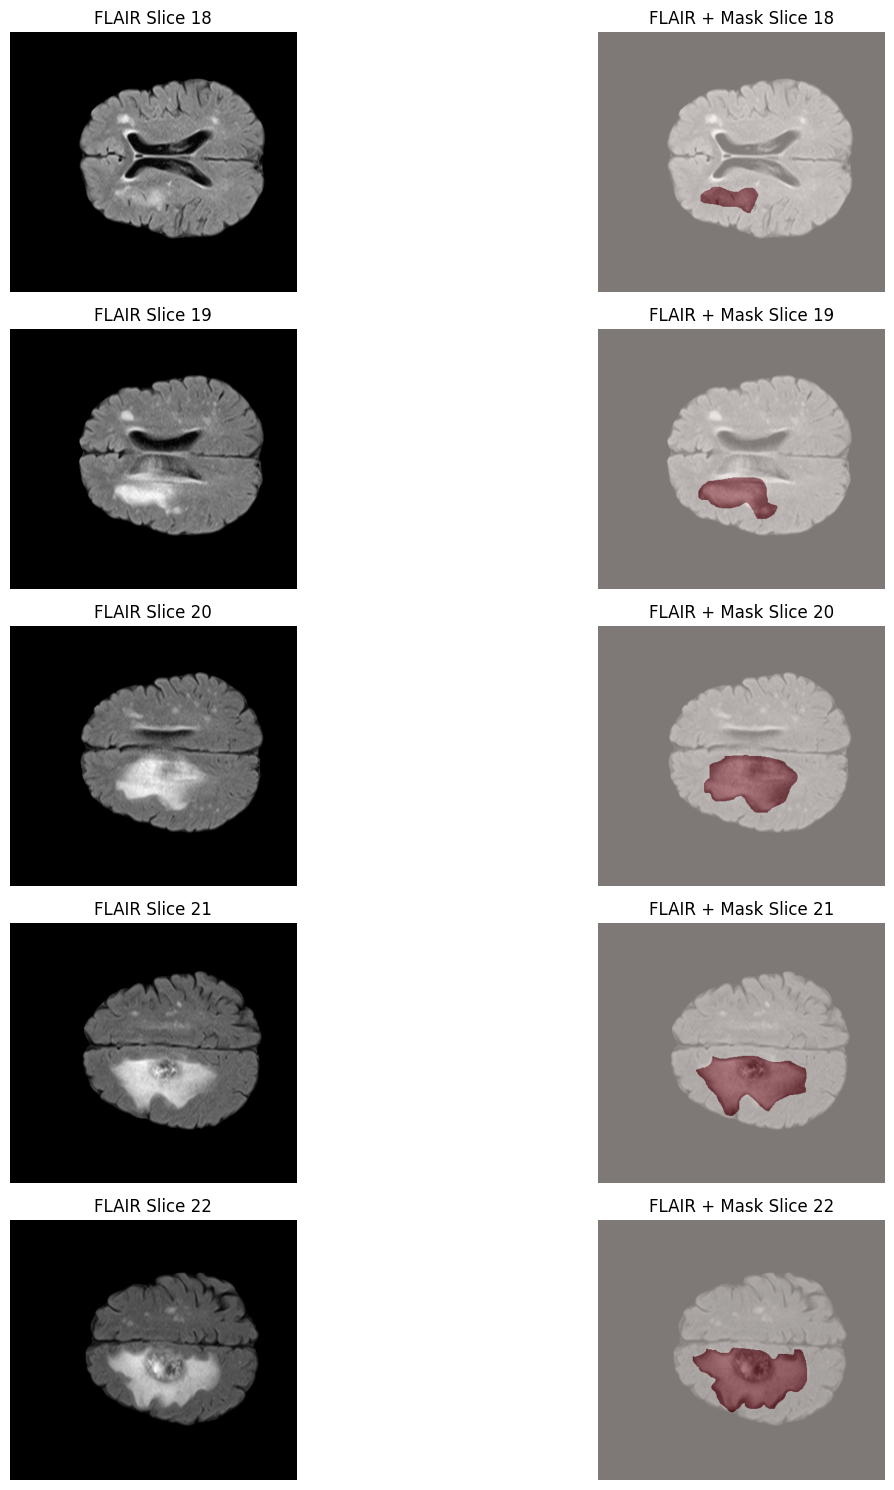

In [2]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# --- Choose patient folder ---
patient_folder = "data/dataset/YG_B5T1BHE5XSV0"  # replace with your folder

# --- Find FLAIR image and mask files ---
flair_file = [f for f in os.listdir(patient_folder) if "_flair_img" in f][0]
mask_file = [f for f in os.listdir(patient_folder) if "_whole_seg" in f][0]

flair_path = os.path.join(patient_folder, flair_file)
mask_path = os.path.join(patient_folder, mask_file)

# --- Load NIfTI images ---
flair_nii = nib.load(flair_path).get_fdata()
mask_nii = nib.load(mask_path).get_fdata()

print("FLAIR shape:", flair_nii.shape)
print("Mask shape:", mask_nii.shape)

# --- Function to map mask slices to image slices if depths differ ---
def get_mask_slice(mask, img_idx, img_depth, mask_depth):
    mask_idx = int(img_idx * mask_depth / img_depth)
    return mask[:,:,mask_idx]

# --- Loop through slices and display only those with tumor ---
img_depth = flair_nii.shape[2]
mask_depth = mask_nii.shape[2]

# Collect slice indices with tumor
tumor_slices = [i for i in range(img_depth) if np.max(get_mask_slice(mask_nii, i, img_depth, mask_depth)) > 0]

print("Number of slices with tumor:", len(tumor_slices))

# Display first few slices with tumor
num_to_show = min(5, len(tumor_slices))

plt.figure(figsize=(15,3*num_to_show))
for idx, slice_idx in enumerate(tumor_slices[:num_to_show]):
    slice_img = flair_nii[:,:,slice_idx]
    slice_mask = get_mask_slice(mask_nii, slice_idx, img_depth, mask_depth)
    slice_mask_bin = (slice_mask > 0).astype(np.float32)

    plt.subplot(num_to_show, 2, idx*2+1)
    plt.imshow(slice_img, cmap="gray")
    plt.title(f"FLAIR Slice {slice_idx}")
    plt.axis("off")

    plt.subplot(num_to_show, 2, idx*2+2)
    plt.imshow(slice_img, cmap="gray")
    plt.imshow(slice_mask_bin, cmap="Reds", alpha=0.5)
    plt.title(f"FLAIR + Mask Slice {slice_idx}")
    plt.axis("off")

plt.tight_layout()
plt.show() 


In [3]:
import numpy as np
from pathlib import Path
import nibabel as nib
import plotly.graph_objects as go
import plotly.io as pio

# Open the 3D plot in a browser
pio.renderers.default = "browser"

# === CONFIG ===
BASE_DIR = Path(r"C:\Users\ahmed\OneDrive\Desktop\class_seg\data\dataset")
patient_id = "YG_0LCI9NV44UK0"  # pick any patient folder
pat_dir = BASE_DIR / patient_id

# fallback to first patient if folder not found
if not pat_dir.exists():
    pat_dir = sorted([p for p in BASE_DIR.iterdir() if p.is_dir()])[0]
    patient_id = pat_dir.name

# === LOAD VOLUMES ===
flair_path = next(pat_dir.glob("*_flair_img.nii.gz"))
mask_path = next(pat_dir.glob("*_whole_seg.nii.gz"))

flair = nib.load(str(flair_path)).get_fdata().astype(np.float32)
mask = nib.load(str(mask_path)).get_fdata().astype(np.float32)

# Normalize FLAIR for visualization (0-1)
flair = (flair - np.min(flair)) / (np.max(flair) - np.min(flair) + 1e-6)

# Optional downsample for speed
ds = 1
flair = flair[::ds, ::ds, ::ds]
mask = mask[::ds, ::ds, ::ds]

# === CREATE FIGURE ===
fig = go.Figure()

# Add FLAIR volume
fig.add_trace(go.Volume(
    value=flair,
    opacity=0.2,         # low opacity to see internal structure
    surface_count=25,    # number of isosurfaces
    colorscale="Gray",
    showscale=False,
    name="FLAIR"
))

# Add segmentation overlay
if np.max(mask) > 0:
    fig.add_trace(go.Isosurface(
        value=mask,
        isomin=0.1,         # show any positive voxel
        isomax=1.0,
        opacity=0.6,        # highlight mask
        surface_count=1,
        colorscale=[[0, "#ff0000"], [1, "#ff0000"]],
        showscale=False,
        name="Mask"
    ))

# Layout
fig.update_layout(
    title=f"Patient {patient_id} — FLAIR + Mask (3D)",
    width=800,
    height=800,
    scene=dict(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False)
)

fig.show()


----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 65099)
Traceback (most recent call last):
  File "C:\Users\ahmed\AppData\Local\Programs\Python\Python311\Lib\socketserver.py", line 317, in _handle_request_noblock
    self.process_request(request, client_address)
  File "C:\Users\ahmed\AppData\Local\Programs\Python\Python311\Lib\socketserver.py", line 348, in process_request
    self.finish_request(request, client_address)
  File "C:\Users\ahmed\AppData\Local\Programs\Python\Python311\Lib\socketserver.py", line 361, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "C:\Users\ahmed\AppData\Local\Programs\Python\Python311\Lib\socketserver.py", line 755, in __init__
    self.handle()
  File "C:\Users\ahmed\AppData\Local\Programs\Python\Python311\Lib\http\server.py", line 431, in handle
    self.handle_one_request()
  File "C:\Users\ahmed\AppData\Local\Programs\Python\Python311\Lib\http\server.py",

In [41]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt

# --- Paths ---
patient_folder = "data/dataset/YG_3XK3D2ZF8DMH"  # replace with your folder
flair_path = f"{patient_folder}/YG_NHXKSO7LZ3OZ_flair_img.nii.gz"
mask_path = f"{patient_folder}/YG_NHXKSO7LZ3OZ_core_seg.nii.gz"

# --- Load images ---
flair_sitk = sitk.ReadImage(flair_path)
mask_sitk = sitk.ReadImage(mask_path)


In [42]:
# Get image properties
image_size = flair_sitk.GetSize()
image_spacing = flair_sitk.GetSpacing()
image_origin = flair_sitk.GetOrigin()
image_direction = flair_sitk.GetDirection()

# Resample mask
resample = sitk.ResampleImageFilter()
resample.SetReferenceImage(flair_sitk)
resample.SetInterpolator(sitk.sitkNearestNeighbor)  # keep labels exact
resample.SetOutputSpacing(image_spacing)
resample.SetSize(image_size)
resample.SetOutputOrigin(image_origin)
resample.SetOutputDirection(image_direction)

mask_resampled = resample.Execute(mask_sitk)


In [43]:
flair_np = sitk.GetArrayFromImage(flair_sitk)        # shape: (D, H, W)
mask_np = sitk.GetArrayFromImage(mask_resampled)      # same shape

# Note: SimpleITK uses (D, H, W), matplotlib uses (H, W)
# We'll pick slices along axis 0 (depth)


Number of slices with tumor: 4


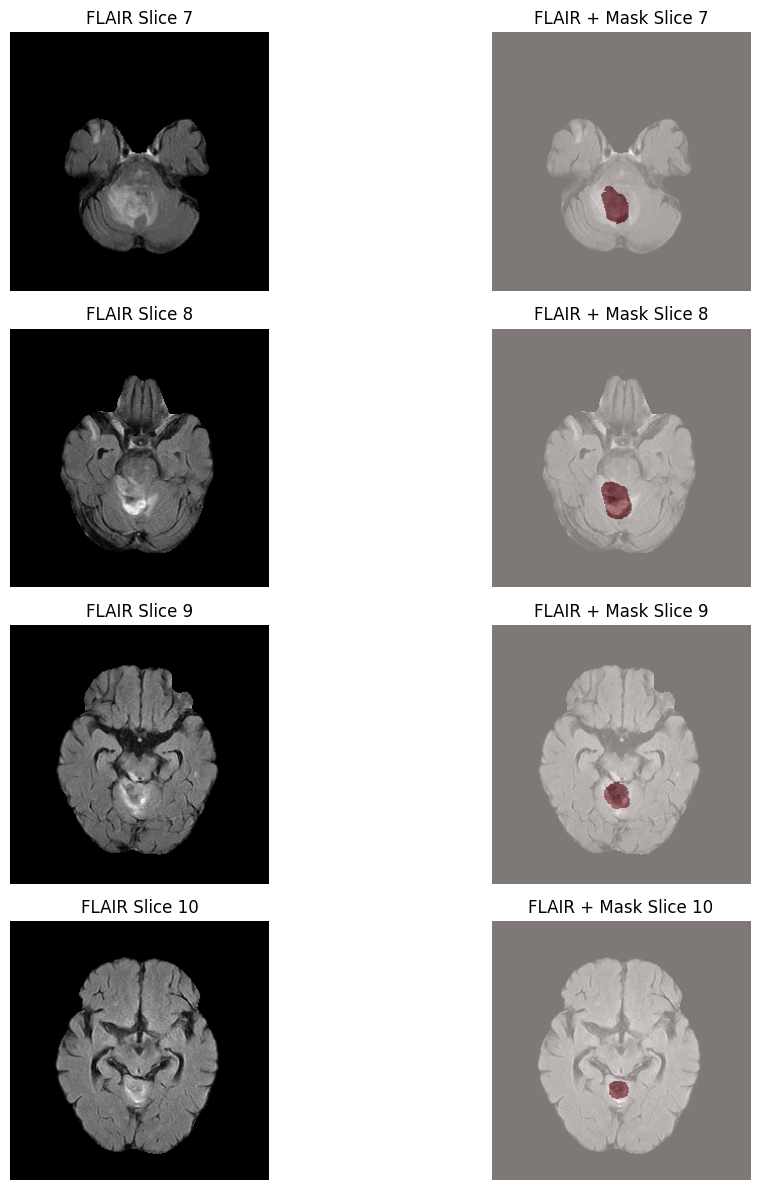

In [44]:
# Find slices with tumor
tumor_slices = [i for i in range(mask_np.shape[0]) if np.max(mask_np[i]) > 0]
print("Number of slices with tumor:", len(tumor_slices))

# Show first 5 slices with tumor
num_to_show = min(5, len(tumor_slices))
plt.figure(figsize=(12, 3*num_to_show))

for idx, slice_idx in enumerate(tumor_slices[:num_to_show]):
    slice_img = flair_np[slice_idx]
    slice_mask = (mask_np[slice_idx] > 0).astype(float)
    
    plt.subplot(num_to_show, 2, idx*2+1)
    plt.imshow(slice_img, cmap="gray")
    plt.title(f"FLAIR Slice {slice_idx}")
    plt.axis("off")
    
    plt.subplot(num_to_show, 2, idx*2+2)
    plt.imshow(slice_img, cmap="gray")
    plt.imshow(slice_mask, cmap="Reds", alpha=0.5)
    plt.title(f"FLAIR + Mask Slice {slice_idx}")
    plt.axis("off")

plt.tight_layout()
plt.show()


# Preprocessing

In [ ]:
import os
from glob import glob
import numpy as np
import SimpleITK as sitk
import nibabel as nib

# ----------------------------
# Preprocessing utilities
# ----------------------------

def read_sitk(path):
    return sitk.ReadImage(path)

# Needed to load raw MRI data and save preprocessed versions.
def save_sitk(img: sitk.Image, out_path: str):
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    sitk.WriteImage(img, out_path)

# Match mask geometry to image
def match_geometry_like(moving: sitk.Image, reference: sitk.Image, is_label: bool) -> sitk.Image:
    resample = sitk.ResampleImageFilter()
    resample.SetReferenceImage(reference)
    resample.SetOutputSpacing(reference.GetSpacing())
    resample.SetSize(reference.GetSize())
    resample.SetOutputOrigin(reference.GetOrigin())
    resample.SetOutputDirection(reference.GetDirection())
    resample.SetInterpolator(sitk.sitkNearestNeighbor if is_label else sitk.sitkBSpline)
    return resample.Execute(moving)

# Removes intensity inhomogeneity (brightness variations across MRI)
# => Standardizes brightness, so the model doesn’t confuse scanner artifacts with real tissue differences.
def n4_bias_correction_safe(img: sitk.Image, num_iterations=(50, 50, 30, 20)) -> sitk.Image:
    # Create a mask using Otsu to focus N4
    img_float = sitk.Cast(img, sitk.sitkFloat32)
    mask = sitk.OtsuThreshold(img_float, 0, 1, 200)
    corrector = sitk.N4BiasFieldCorrectionImageFilter()
    corrector.SetMaximumNumberOfIterations(num_iterations)
    corrected = corrector.Execute(img_float, mask)
    return corrected

# Standardizes intensities across patients → important for neural networks.
def robust_zscore_normalize(img: sitk.Image) -> sitk.Image:
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    # Mask intensities using Otsu foreground
    brain_mask = arr > np.percentile(arr, 50)  # fallback simple mask
    try:
        otsu = sitk.OtsuThreshold(sitk.GetImageFromArray(arr), 0, 1, 200)
        brain_mask = sitk.GetArrayFromImage(otsu).astype(bool)
    except Exception:
        pass
    vals = arr[brain_mask]
    if vals.size < 10:
        vals = arr[arr > np.percentile(arr, 20)]
    p10, p99 = np.percentile(vals, [10, 99])
    clipped = np.clip(arr, p10, p99)
    mean = clipped[brain_mask].mean() if brain_mask.any() else clipped.mean()
    std = clipped[brain_mask].std() if brain_mask.any() else clipped.std()
    std = std if std > 1e-6 else 1.0
    norm = (clipped - mean) / std
    out = sitk.GetImageFromArray(norm.astype(np.float32))
    out.CopyInformation(img)
    return out

# Models don’t need to see black background → improves training speed and accuracy.
def crop_to_foreground(image: sitk.Image, mask: sitk.Image = None, margin: int = 8, return_coords: bool = False):
    arr = sitk.GetArrayFromImage(mask if mask is not None else image)
    if mask is None:
        arr = arr > np.percentile(arr, 75)
    coords_arr = np.array(np.nonzero(arr))  # (3, N)
    
    if coords_arr.size == 0:
        if return_coords:
            return image, mask, (0, arr.shape[2], 0, arr.shape[1], 0, arr.shape[0])
        else:
            return image, mask
    
    minc = np.maximum(coords_arr.min(axis=1) - margin, 0)
    maxc = np.minimum(coords_arr.max(axis=1) + margin + 1, arr.shape)
    
    extractor = sitk.RegionOfInterestImageFilter()
    size = [int(maxc[2]-minc[2]), int(maxc[1]-minc[1]), int(maxc[0]-minc[0])]
    index = [int(minc[2]), int(minc[1]), int(minc[0])]
    extractor.SetSize(size)
    extractor.SetIndex(index)
    
    img_c = extractor.Execute(image)
    msk_c = extractor.Execute(mask) if mask is not None else None
    
    if return_coords:
        # Return in (x1,x2,y1,y2,z1,z2) order
        coords = (index[0], index[0]+size[0], index[1], index[1]+size[1], index[2], index[2]+size[2])
        return img_c, msk_c, coords
    else:
        return img_c, msk_c

def preprocess_case(flair_path: str, mask_path: str = None, return_coords: bool = False):
    # Read
    flair = read_sitk(flair_path)
    mask = read_sitk(mask_path) if mask_path is not None else None

    # Align mask to FLAIR geometry if provided
    if mask is not None:
        mask_aligned = match_geometry_like(mask, flair, is_label=True)
    else:
        mask_aligned = None

    # N4 bias correction + normalization
    flair_corr = n4_bias_correction_safe(flair)
    flair_norm = robust_zscore_normalize(flair_corr)

    # Crop to tumor foreground, if any
    if return_coords:
        flair_crop, mask_crop, coords = crop_to_foreground(flair_norm, mask_aligned, return_coords=True)
        return flair_crop, mask_crop, coords
    else:
        flair_crop, mask_crop = crop_to_foreground(flair_norm, mask_aligned)
        return flair_crop, mask_crop


# Pipeline steps applied in order:

# 1/ Load FLAIR & mask → loading

# 2/Align mask → resampling/alignment

# 3/ N4 + normalize → intensity correction & normalization

# 4/ Crop → focus on brain/tumor region

# ==> Output: Preprocessed image + mask, ready for training or slice extraction.

""" def preprocess_case(flair_path: str, mask_path: str):
    # Read
    flair = read_sitk(flair_path)
    mask = read_sitk(mask_path)

    # Align mask to FLAIR geometry
    mask_aligned = match_geometry_like(mask, flair, is_label=True)

    # N4 bias correction + normalization
    flair_corr = n4_bias_correction_safe(flair)
    flair_norm = robust_zscore_normalize(flair_corr)

    # Crop to tumor foreground, if any
    flair_crop, mask_crop = crop_to_foreground(flair_norm, mask_aligned)

    return flair_crop, mask_crop """

# Searches a patient folder and returns paths to FLAIR image + whole segmentation mask
# Helps you loop over all patients without hardcoding filenames.
def find_pair(folder: str):
    flair = None
    msk = None
    for f in os.listdir(folder):
        if f.endswith('.nii.gz') and '_flair_img' in f:
            flair = os.path.join(folder, f)
        if f.endswith('.nii.gz') and '_whole_seg' in f:
            msk = os.path.join(folder, f)
    return flair, msk



In [ ]:
import random

# ----------------------------
# Batch processor
# ----------------------------

def process_split(split_dir: str, out_root: str):
    in_cases = [d for d in glob(os.path.join(split_dir, '*')) if os.path.isdir(d)]
    print(f"Found {len(in_cases)} cases in {split_dir}")
    for case_dir in in_cases:
        flair_path, mask_path = find_pair(case_dir)
        if flair_path is None or mask_path is None:
            print(f"Skip {case_dir}: pair not found")
            continue
        try:
            flair_p, mask_p = preprocess_case(flair_path, mask_path)
        except Exception as e:
            print(f"Error processing {case_dir}: {e}")
            continue
        rel = os.path.basename(case_dir)
        out_case = os.path.join(out_root, rel)
        save_sitk(flair_p, os.path.join(out_case, 'flair_pre.nii.gz'))
        if mask_p is not None:
            # ensure binary (whole tumor)
            mask_bin = sitk.Cast(sitk.Greater(mask_p, 0), sitk.sitkUInt8)
            save_sitk(mask_bin, os.path.join(out_case, 'mask_pre.nii.gz'))
    print("Done.")

# Example run (uncomment to execute):
process_split('data/split_dataset/train', 'data/preprocessed/train')
process_split('data/split_dataset/test', 'data/preprocessed/test')


Found 82 cases in data/split_dataset/train


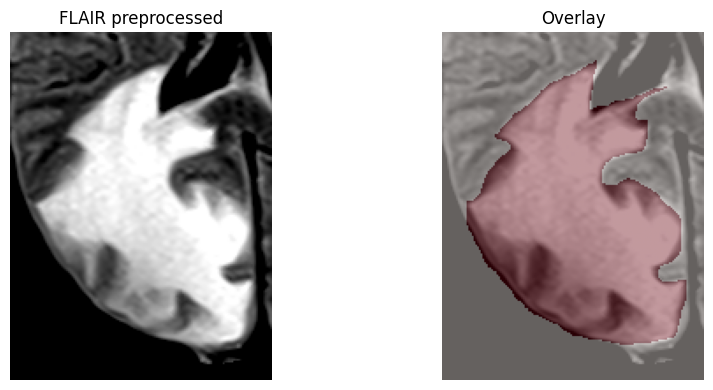

In [ ]:
import matplotlib.pyplot as plt

# ----------------------------
# Quick QA visualization
# ----------------------------

def show_random_case(pre_dir: str):
    cases = [d for d in glob(os.path.join(pre_dir, '*')) if os.path.isdir(d)]
    if not cases:
        print("No cases found.")
        return
    case = random.choice(cases)
    flair_p = os.path.join(case, 'flair_pre.nii.gz')
    mask_p = os.path.join(case, 'mask_pre.nii.gz')
    if not os.path.exists(flair_p) or not os.path.exists(mask_p):
        print(f"Missing files in {case}")
        return
    img = sitk.ReadImage(flair_p)
    msk = sitk.ReadImage(mask_p)
    img_np = sitk.GetArrayFromImage(img)
    msk_np = sitk.GetArrayFromImage(msk)
    # pick middle slice that has tumor
    tumor_idxs = [i for i in range(msk_np.shape[0]) if msk_np[i].max()>0]
    if tumor_idxs:
        idx = tumor_idxs[len(tumor_idxs)//2]
    else:
        idx = img_np.shape[0]//2
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(img_np[idx], cmap='gray')
    plt.title('FLAIR preprocessed')
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(img_np[idx], cmap='gray')
    plt.imshow(msk_np[idx].astype(float), cmap='Reds', alpha=0.4)
    plt.title('Overlay')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Example QA (uncomment after processing):
show_random_case('data/preprocessed/train')


# training

In [5]:
# ----------------------------
# PyTorch 3D U-Net - setup
# ----------------------------
import os
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import nibabel as nib
import SimpleITK as sitk

class Config:
    train_dir = 'data/preprocessed/train'
    test_dir = 'data/preprocessed/test'
    out_dir = 'outputs'
    # training
    epochs = 50
    batch_size = 1
    num_workers = 2
    lr = 1e-3
    weight_decay = 1e-5
    amp = True
    ckpt_every = 5
    # data
    patch_size = (128, 128, 64)   # (D, H, W)
    samples_per_volume = 2
    augment = True
    # model
    in_channels = 1
    out_channels = 1
    base_ch = 24
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

os.makedirs(Config.out_dir, exist_ok=True)
print('Using device:', Config.device)


Using device: cuda


In [9]:
# ----------------------------
# Dataset & Dataloaders
# ----------------------------
from glob import glob

class VolumeIndex:
    def __init__(self, img_path, msk_path):
        self.img = img_path
        self.msk = msk_path


def list_cases(root):
    cases = []
    for case_dir in sorted(glob(os.path.join(root, '*'))):
        img = os.path.join(case_dir, 'flair_pre.nii.gz')
        msk = os.path.join(case_dir, 'mask_pre.nii.gz')
        if os.path.exists(img) and os.path.exists(msk):
            cases.append(VolumeIndex(img, msk))
    return cases


def random_crop_3d(img, msk, patch_size):
    d, h, w = img.shape
    pd, ph, pw = patch_size
    if d < pd or h < ph or w < pw:
        # pad reflect
        pad = ((0, max(0, pd - d)), (0, max(0, ph - h)), (0, max(0, pw - w)))
        img = np.pad(img, pad, mode='reflect')
        msk = np.pad(msk, pad, mode='constant')
        d, h, w = img.shape
    sd = random.randint(0, d - pd)
    sh = random.randint(0, h - ph)
    sw = random.randint(0, w - pw)
    return img[sd:sd+pd, sh:sh+ph, sw:sw+pw], msk[sd:sd+pd, sh:sh+ph, sw:sw+pw]


def augment3d(img, msk):
    # simple random flips
    for axis in [0,1,2]:
        if random.random() < 0.5:
            img = np.flip(img, axis=axis).copy()
            msk = np.flip(msk, axis=axis).copy()
    return img, msk


class BrainSegDataset(Dataset):
    def __init__(self, root, patch_size, samples_per_volume=2, augment=True):
        self.items = list_cases(root)
        self.patch_size = patch_size
        self.samples_per_volume = samples_per_volume
        self.augment = augment

    def __len__(self):
        return len(self.items) * self.samples_per_volume

    def __getitem__(self, idx):
        vi = self.items[idx // self.samples_per_volume]
        img = sitk.GetArrayFromImage(sitk.ReadImage(vi.img)).astype(np.float32)
        msk = sitk.GetArrayFromImage(sitk.ReadImage(vi.msk)).astype(np.float32)
        img, msk = random_crop_3d(img, msk, self.patch_size)
        if self.augment:
            img, msk = augment3d(img, msk)
        # to tensor (C, D, H, W)
        img = torch.from_numpy(img[None, ...])
        msk = torch.from_numpy(msk[None, ...])
        return img, msk


def make_loaders():
    train_ds = BrainSegDataset(Config.train_dir, Config.patch_size, Config.samples_per_volume, Config.augment)
    test_ds = BrainSegDataset(Config.test_dir, Config.patch_size, 1, augment=False)
    train_loader = DataLoader(train_ds, batch_size=Config.batch_size, shuffle=True, num_workers=Config.num_workers, pin_memory=True)
    val_loader = DataLoader(test_ds, batch_size=Config.batch_size, shuffle=False, num_workers=Config.num_workers, pin_memory=True)
    return train_loader, val_loader

train_loader, val_loader = make_loaders()
print(f"Train iters/epoch: {len(train_loader)} | Val iters: {len(val_loader)}")


Train iters/epoch: 154 | Val iters: 19


In [6]:
# ----------------------------
# 3D U-Net model (compact)
# ----------------------------

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UNet3D(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=24):
        super().__init__()
        b = base
        self.enc1 = ConvBlock(in_ch, b)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = ConvBlock(b, b*2)
        self.pool2 = nn.MaxPool3d(2)
        self.enc3 = ConvBlock(b*2, b*4)
        self.pool3 = nn.MaxPool3d(2)
        self.bott = ConvBlock(b*4, b*8)

        self.up3 = nn.ConvTranspose3d(b*8, b*4, 2, stride=2)
        self.dec3 = ConvBlock(b*8, b*4)
        self.up2 = nn.ConvTranspose3d(b*4, b*2, 2, stride=2)
        self.dec2 = ConvBlock(b*4, b*2)
        self.up1 = nn.ConvTranspose3d(b*2, b, 2, stride=2)
        self.dec1 = ConvBlock(b*2, b)
        self.head = nn.Conv3d(b, out_ch, 1)

    def forward(self, x):
        # Encoder (downsampling)
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        # Bottleneck
        bt = self.bott(self.pool3(e3))
        # Decoder (upsampling + skip connections)
        d3 = self.up3(bt)
        d3 = torch.cat([d3, e3], dim=1) # skip connection => concatination
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return self.head(d1) # final output: (N, out_ch, D, H, W)

model = UNet3D(Config.in_channels, Config.out_channels, Config.base_ch).to(Config.device)
print('Model params:', sum(p.numel() for p in model.parameters())/1e6, 'M')


Model params: 3.151369 M


In [8]:
# ----------------------------
# Losses & Metrics
# ----------------------------

def dice_coeff(pred, target, eps=1e-6):
    # pred, target: (N, 1, D, H, W), pred is probabilities
    pred = pred.reshape(pred.size(0), -1)
    target = target.reshape(target.size(0), -1)
    inter = (pred * target).sum(dim=1)
    denom = pred.sum(dim=1) + target.sum(dim=1)
    return ((2 * inter + eps) / (denom + eps)).mean()

class DiceBCELoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.w = bce_weight
    def forward(self, logits, target):
        bce = self.bce(logits, target)
        probs = torch.sigmoid(logits)
        d = 1.0 - dice_coeff(probs, target)
        return self.w * bce + (1 - self.w) * d

criterion = DiceBCELoss().to(Config.device)


In [7]:
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())


CUDA available: True
Device count: 1
GPU name: NVIDIA GeForce RTX 2050
Current device index: 0


In [10]:
# ----------------------------
# Fix DataLoader issue
# ----------------------------
# The DataLoader workers are crashing. Let's fix this by:
# 1. Setting num_workers=0 to disable multiprocessing
# 2. Making the dataset more robust

Config.num_workers = 0  # Disable multiprocessing

# Recreate the dataset with error handling
class RobustBrainSegDataset(Dataset):
    def __init__(self, root, patch_size, samples_per_volume=2, augment=True):
        self.items = list_cases(root)
        self.patch_size = patch_size
        self.samples_per_volume = samples_per_volume
        self.augment = augment
        print(f"Found {len(self.items)} cases in {root}")

    def __len__(self):
        return len(self.items) * self.samples_per_volume

    def __getitem__(self, idx):
        try:
            vi = self.items[idx // self.samples_per_volume]
            img = sitk.GetArrayFromImage(sitk.ReadImage(vi.img)).astype(np.float32)
            msk = sitk.GetArrayFromImage(sitk.ReadImage(vi.msk)).astype(np.float32)
            
            # Ensure we have valid data
            if img.size == 0 or msk.size == 0:
                raise ValueError("Empty image or mask")
                
            img, msk = random_crop_3d(img, msk, self.patch_size)
            if self.augment:
                img, msk = augment3d(img, msk)
            
            # to tensor (C, D, H, W)
            img = torch.from_numpy(img[None, ...])
            msk = torch.from_numpy(msk[None, ...])
            return img, msk
        except Exception as e:
            print(f"Error loading item {idx}: {e}")
            # Return a dummy sample to avoid crashes
            dummy_img = torch.zeros(1, *self.patch_size)
            dummy_msk = torch.zeros(1, *self.patch_size)
            return dummy_img, dummy_msk

# Recreate loaders with robust dataset
train_ds = RobustBrainSegDataset(Config.train_dir, Config.patch_size, Config.samples_per_volume, Config.augment)
test_ds = RobustBrainSegDataset(Config.test_dir, Config.patch_size, 1, augment=False)

train_loader = DataLoader(train_ds, batch_size=Config.batch_size, shuffle=True, num_workers=Config.num_workers, pin_memory=False)
val_loader = DataLoader(test_ds, batch_size=Config.batch_size, shuffle=False, num_workers=Config.num_workers, pin_memory=False)

print(f"Fixed! Train iters/epoch: {len(train_loader)} | Val iters: {len(val_loader)}")


Found 77 cases in data/preprocessed/train
Found 19 cases in data/preprocessed/test
Fixed! Train iters/epoch: 154 | Val iters: 19


In [25]:
# ----------------------------
# Train loop with AMP & ckpt
# ----------------------------
from torch.cuda.amp import autocast, GradScaler

optimizer = torch.optim.AdamW(model.parameters(), lr=Config.lr, weight_decay=Config.weight_decay)
scaler = GradScaler(enabled=Config.amp)

best_dice = 0.0

def validate():
    model.eval()
    dices = []
    with torch.no_grad():
        for imgs, msks in val_loader:
            imgs = imgs.to(Config.device, non_blocking=True)
            msks = msks.to(Config.device, non_blocking=True)
            with autocast(enabled=Config.amp):
                logits = model(imgs)
                probs = torch.sigmoid(logits)
            dices.append(dice_coeff(probs, msks).item())
    model.train()
    return np.mean(dices) if dices else 0.0

for epoch in range(1, Config.epochs+1):
    model.train()
    running_loss = 0.0
    for step, (imgs, msks) in enumerate(train_loader, 1):
        imgs = imgs.to(Config.device, non_blocking=True)
        msks = msks.to(Config.device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=Config.amp):
            logits = model(imgs)
            loss = criterion(logits, msks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        if step % 20 == 0:
            print(f"Epoch {epoch} Step {step}/{len(train_loader)} | Loss {running_loss/step:.4f}")

    val_dice = validate()
    print(f"Epoch {epoch} done. Val Dice: {val_dice:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save({'epoch': epoch,
                    'model': model.state_dict(),
                    'opt': optimizer.state_dict(),
                    'dice': best_dice}, os.path.join(Config.out_dir, 'best.pth'))
        print("Saved best checkpoint.")

    if epoch % Config.ckpt_every == 0:
        torch.save({'epoch': epoch,
                    'model': model.state_dict(),
                    'opt': optimizer.state_dict()}, os.path.join(Config.out_dir, f'epoch_{epoch}.pth'))
        print("Saved periodic checkpoint.")


C:\Users\ahmed\AppData\Local\Temp\ipykernel_17644\802206325.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=Config.amp)
C:\Users\ahmed\AppData\Local\Temp\ipykernel_17644\802206325.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=Config.amp):


Epoch 1 Step 20/154 | Loss 0.1895
Epoch 1 Step 40/154 | Loss 0.1883
Epoch 1 Step 60/154 | Loss 0.1850
Epoch 1 Step 80/154 | Loss 0.1790
Epoch 1 Step 100/154 | Loss 0.1724


KeyboardInterrupt: 

In [11]:
import torch

ckpt_path = "outputs/best.pth"
ckpt = torch.load(ckpt_path, Config.device)  

print(ckpt.keys())

print("Saved at epoch:", ckpt['epoch'])
print("Best validation Dice:", ckpt['dice'])

total_params = sum(p.numel() for p in ckpt['model'].values())
print("Total parameters:", total_params)



dict_keys(['epoch', 'model', 'opt', 'dice'])
Saved at epoch: 43
Best validation Dice: 0.5129392282305114
Total parameters: 3153495


C:\Users\ahmed\AppData\Local\Temp\ipykernel_25880\1071928032.py:4: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



# Testing

In [12]:
# ----------------------------
# Inference: sliding window + save NIfTI
# ----------------------------
from torch.cuda.amp import autocast, GradScaler
from pathlib import Path

def sliding_window_predict(img_np, patch_size, overlap=0.5):
    # img_np: (D,H,W)
    model.eval()
    pd, ph, pw = patch_size
    d, h, w = img_np.shape
    sd = max(1, int(pd * (1-overlap)))
    sh = max(1, int(ph * (1-overlap)))
    sw = max(1, int(pw * (1-overlap)))

    prob = np.zeros((d,h,w), dtype=np.float32)
    count = np.zeros((d,h,w), dtype=np.float32)

    for z in range(0, max(1, d-pd+1), sd):
        for y in range(0, max(1, h-ph+1), sh):
            for x in range(0, max(1, w-pw+1), sw):
                patch = img_np[z:z+pd, y:y+ph, x:x+pw]
                if patch.shape != (pd,ph,pw):
                    pad = ((0, pd - patch.shape[0]), (0, ph - patch.shape[1]), (0, pw - patch.shape[2]))
                    patch = np.pad(patch, pad, mode='reflect')
                with torch.no_grad():
                    tin = torch.from_numpy(patch[None, None, ...]).to(Config.device)
                    with autocast(enabled=Config.amp):
                        logits = model(tin)
                        p = torch.sigmoid(logits).float().cpu().numpy()[0,0]
                prob[z:z+pd, y:y+ph, x:x+pw] += p[:min(pd,d-z), :min(ph,h-y), :min(pw,w-x)]
                count[z:z+pd, y:y+ph, x:x+pw] += 1.0
    count[count==0] = 1.0
    return prob / count


def run_inference_on_case(case_dir, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    
    case_dir = Path(case_dir)
    
    # Find the FLAIR image ending with _flair_img.nii.gz
    flair_files = list(case_dir.glob("*_flair_img.nii.gz"))
    if not flair_files:
        raise FileNotFoundError(f"No FLAIR image found in {case_dir}")
    img_path = flair_files[0]
    
    # Load image
    img_sitk = sitk.ReadImage(str(img_path))
    img_np = sitk.GetArrayFromImage(img_sitk).astype(np.float32)
    
    # Predict using your sliding window function
    probs = sliding_window_predict(img_np, Config.patch_size)
    
    # Threshold to get binary mask
    pred = (probs > 0.5).astype(np.uint8)
    
    # Convert back to SimpleITK image and save
    pred_img = sitk.GetImageFromArray(pred)
    pred_img.CopyInformation(img_sitk)
    sitk.WriteImage(pred_img, os.path.join(out_dir, 'pred_mask.nii.gz'))

# Example (after training):
# Load the best model
ckpt = torch.load(os.path.join(Config.out_dir, 'best.pth'), map_location=Config.device)
model.load_state_dict(ckpt['model'])

# Run inference on one test case
run_inference_on_case(
    os.path.join("data\dataset", 'YG_0AXGKD8AFJGS'),
    os.path.join(Config.out_dir, 'infer_YG_0AXGKD8AFJGS')
)


C:\Users\ahmed\AppData\Local\Temp\ipykernel_25880\2248162794.py:65: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

C:\Users\ahmed\AppData\Local\Temp\ipykernel_25880\224816279

In [73]:
# ----------------------------
# Visualize predictions vs ground truth
# ----------------------------
import matplotlib.pyplot as plt

def compare_prediction_gt(case_name, test_dir='data/preprocessed/test', pred_dir='outputs'):
    """
    Compare original FLAIR, ground truth mask, and predicted mask
    """
    # Load original FLAIR
    flair_path = os.path.join(test_dir, case_name, 'flair_pre.nii.gz')
    gt_mask_path = os.path.join(test_dir, case_name, 'mask_pre.nii.gz')
    pred_mask_path = os.path.join(pred_dir, f'infer_{case_name}', 'pred_mask.nii.gz')
    
    if not all(os.path.exists(p) for p in [flair_path, gt_mask_path, pred_mask_path]):
        print(f"Missing files for case {case_name}")
        return
    
    # Load images
    flair_img = sitk.ReadImage(flair_path)
    gt_mask = sitk.ReadImage(gt_mask_path)
    pred_mask = sitk.ReadImage(pred_mask_path)
    
    # Convert to numpy
    flair_np = sitk.GetArrayFromImage(flair_img)
    gt_np = sitk.GetArrayFromImage(gt_mask)
    pred_np = sitk.GetArrayFromImage(pred_mask)
    
    # Find slices with tumor in ground truth
    tumor_slices = [i for i in range(gt_np.shape[0]) if gt_np[i].max() > 0]
    
    if not tumor_slices:
        print(f"No tumor found in ground truth for {case_name}")
        return
    
    # Show first few slices with tumor
    num_slices = min(3, len(tumor_slices))
    fig, axes = plt.subplots(num_slices, 3, figsize=(15, 5*num_slices))
    if num_slices == 1:
        axes = axes.reshape(1, -1)
    
    for i, slice_idx in enumerate(tumor_slices[:num_slices]):
        # Original FLAIR
        axes[i, 0].imshow(flair_np[slice_idx], cmap='gray')
        axes[i, 0].set_title(f'Original FLAIR (Slice {slice_idx})')
        axes[i, 0].axis('off')
        
        # Ground Truth Overlay
        axes[i, 1].imshow(flair_np[slice_idx], cmap='gray')
        axes[i, 1].imshow(gt_np[slice_idx], cmap='Reds', alpha=0.6)
        axes[i, 1].set_title(f'Ground Truth (Slice {slice_idx})')
        axes[i, 1].axis('off')
        
        # Prediction Overlay
        axes[i, 2].imshow(flair_np[slice_idx], cmap='gray')
        axes[i, 2].imshow(pred_np[slice_idx], cmap='Blues', alpha=0.6)
        axes[i, 2].set_title(f'Prediction (Slice {slice_idx})')
        axes[i, 2].axis('off')
    
    plt.suptitle(f'Case: {case_name}', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Calculate Dice score for this case
    gt_flat = gt_np.flatten()
    pred_flat = pred_np.flatten()
    
    intersection = np.sum(gt_flat * pred_flat)
    union = np.sum(gt_flat) + np.sum(pred_flat)
    dice = (2.0 * intersection) / (union + 1e-6)
    
    print(f"Dice Score for {case_name}: {dice:.4f}")
    print(f"Ground truth volume: {np.sum(gt_np)} voxels")
    print(f"Predicted volume: {np.sum(pred_np)} voxels")

# Example usage - compare the first case in test set
test_cases = [d for d in os.listdir('data/preprocessed/test') if os.path.isdir(os.path.join('data/preprocessed/test', d))]
if test_cases:
    first_case = test_cases[0]
    print(f"Comparing case: {first_case}")
    compare_prediction_gt(first_case)
else:
    print("No test cases found!") 


Comparing case: YG_0427RC24FT6W
Missing files for case YG_0427RC24FT6W


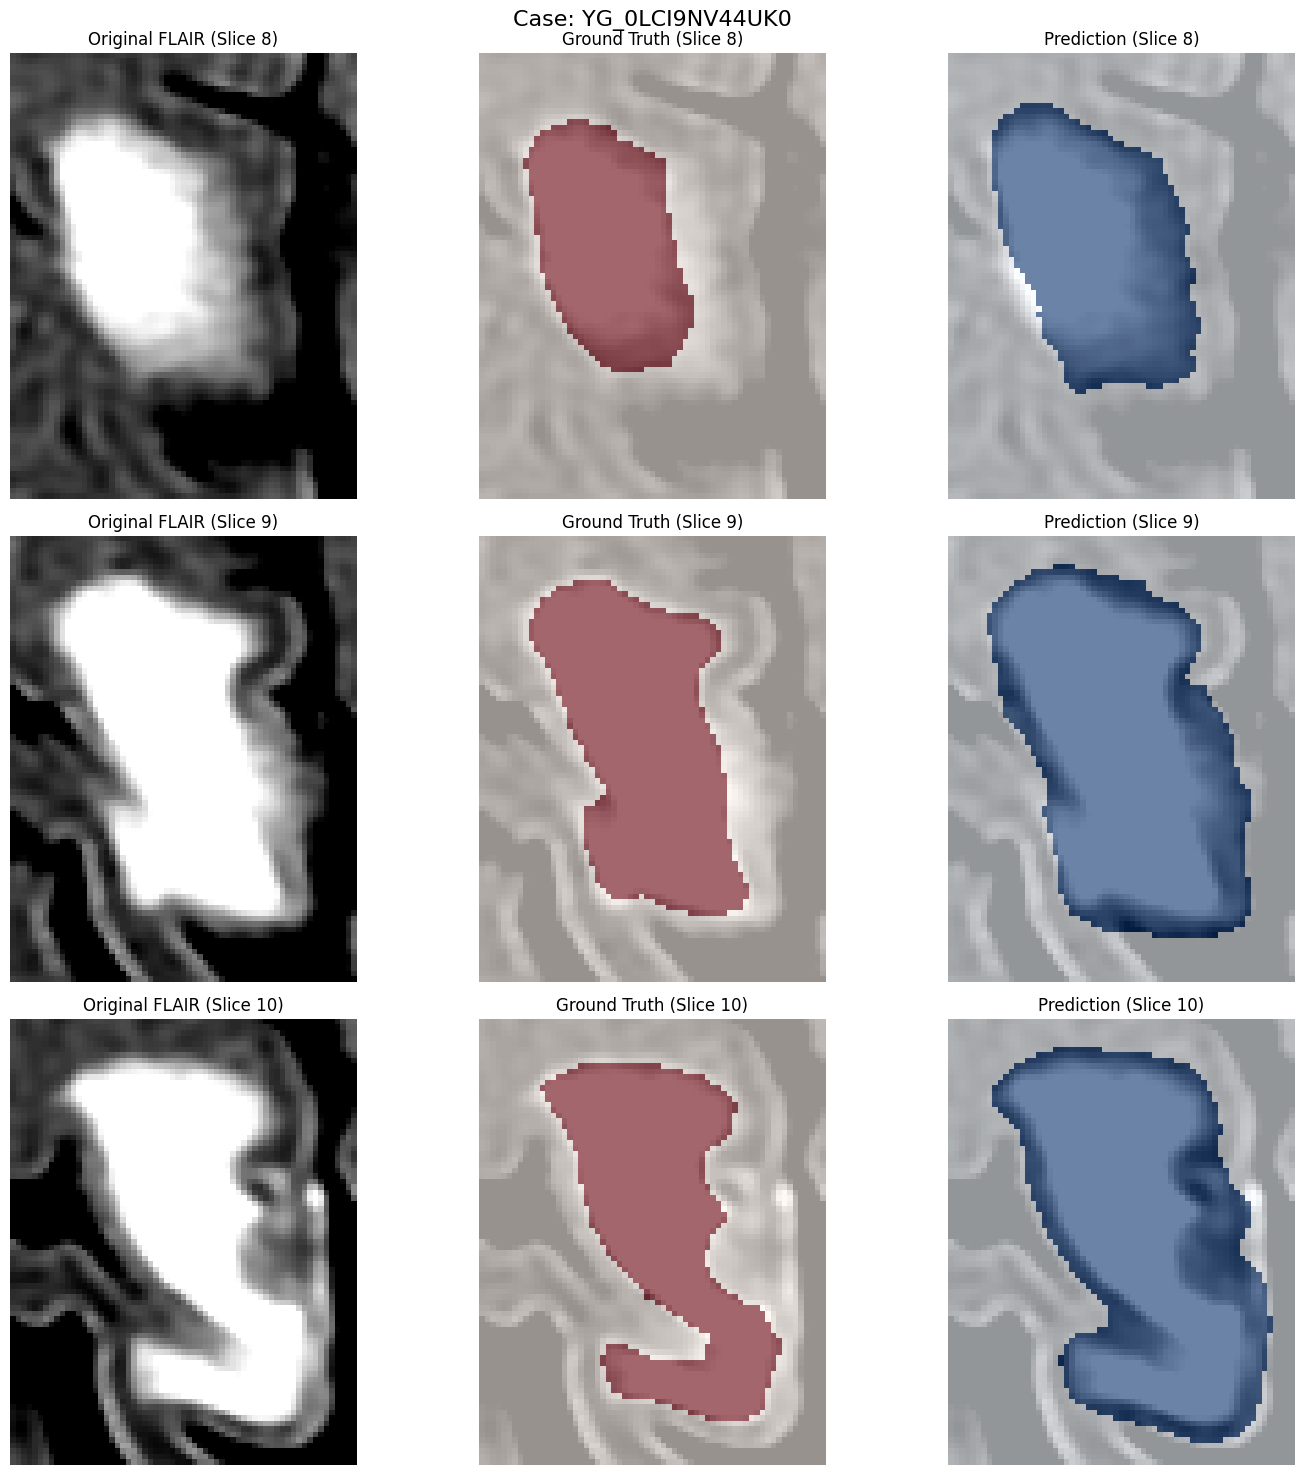

Dice Score for YG_0LCI9NV44UK0: 0.7461
Ground truth volume: 5373 voxels
Predicted volume: 8899 voxels


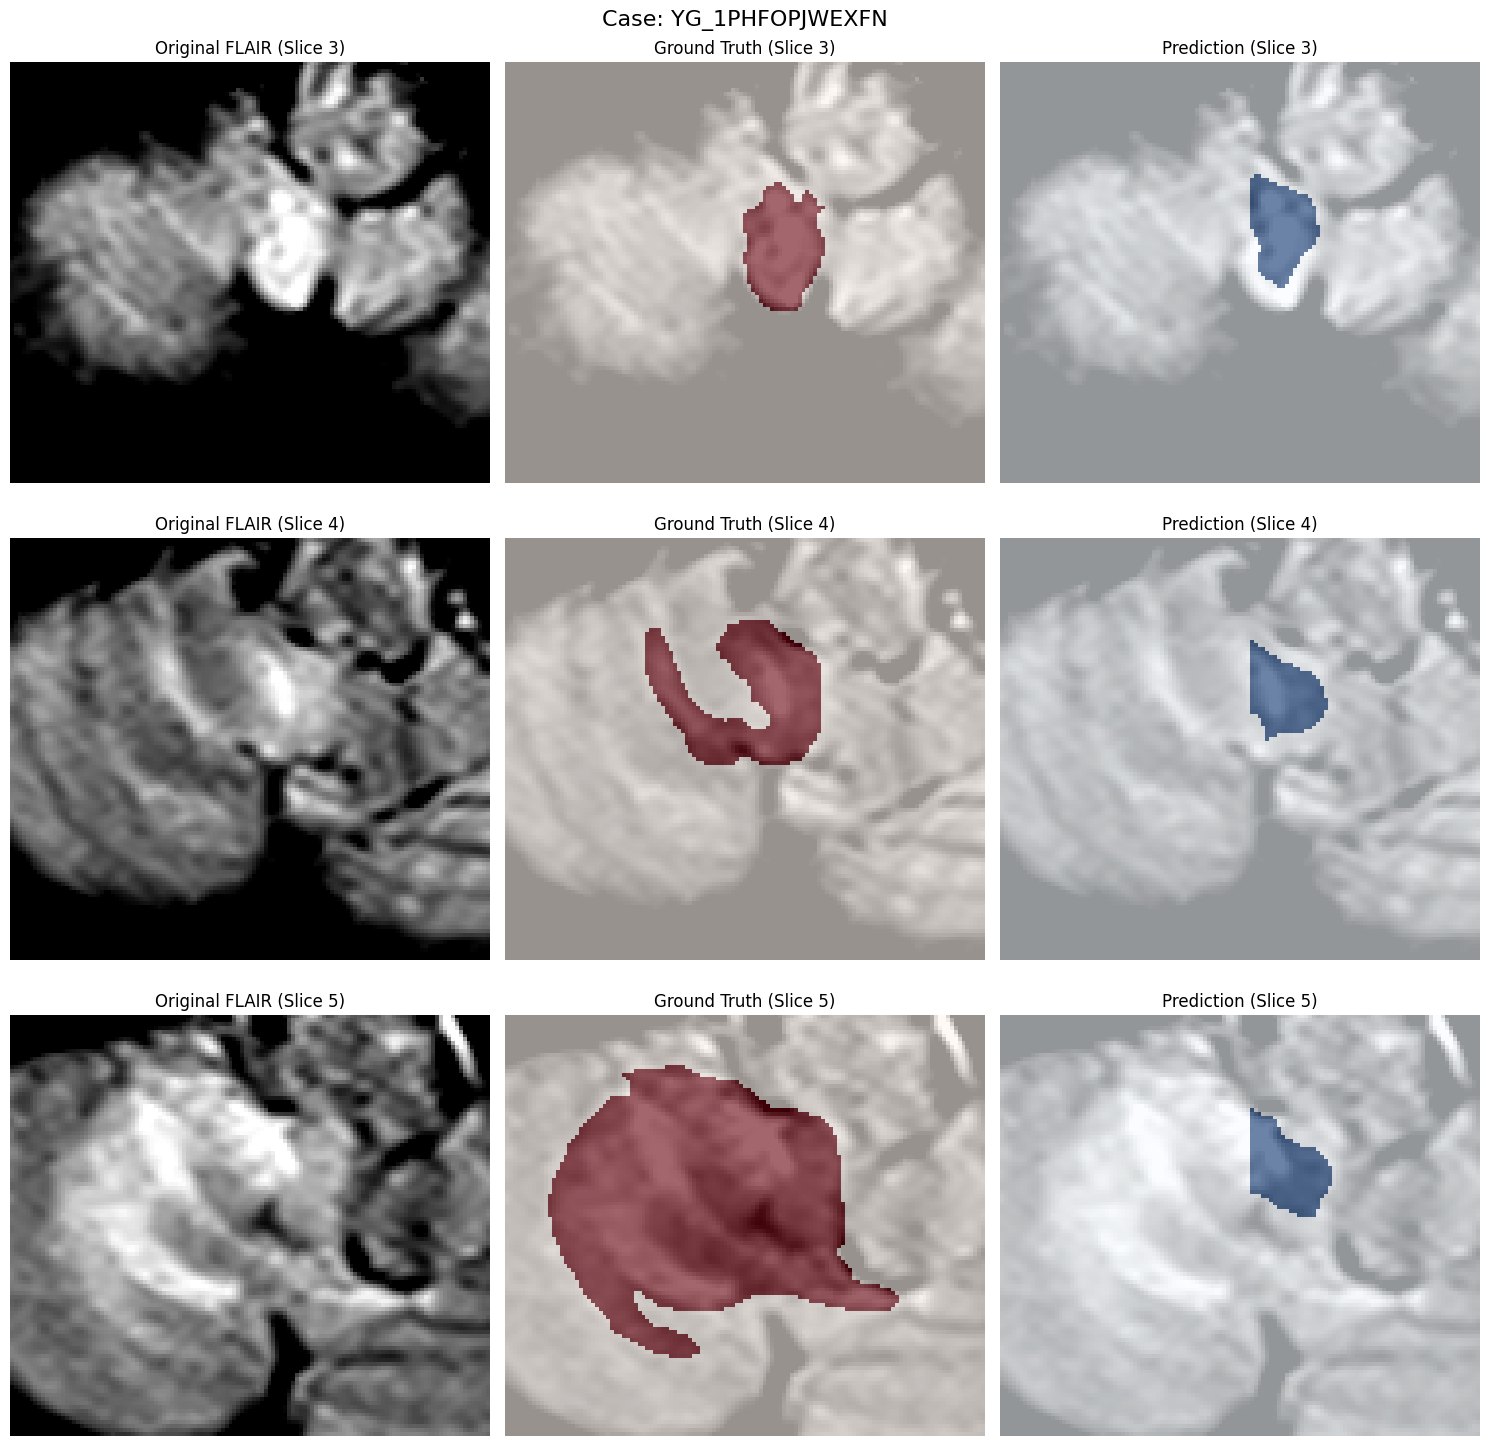

Dice Score for YG_1PHFOPJWEXFN: 0.4627
Ground truth volume: 25950 voxels
Predicted volume: 10431 voxels


In [74]:
# Compare a specific case


# Or compare multiple cases
for case in ['YG_0LCI9NV44UK0', 'YG_1PHFOPJWEXFN']:
    compare_prediction_gt(case)

# 3D visualisation

In [5]:
flair_path = "data/dataset/YG_0LCI9NV44UK0/YG_WNJIJZXQW7BT_flair_img.nii.gz"
mask_path = "data/dataset/YG_0LCI9NV44UK0/YG_WNJIJZXQW7BT_whole_seg.nii.gz"
# If your preprocess_case requires mask_path but you don’t have one at inference, adapt function to make it optional
flair_p, mask_p = preprocess_case(flair_path, mask_path)  

arr = sitk.GetArrayFromImage(flair_p)
print("Preprocessed numpy shape:", arr.shape)

# If you want original SimpleITK size (x,y,z)
print("SimpleITK size:", flair_p.GetSize())

Preprocessed numpy shape: (16, 81, 63)
SimpleITK size: (63, 81, 16)


In [16]:
import nibabel as nib
import numpy as np
import torch
import SimpleITK as sitk

flair_path = "data/dataset/YG_0LCI9NV44UK0/YG_WNJIJZXQW7BT_flair_img.nii.gz"
mask_path  = "data/dataset/YG_0LCI9NV44UK0/YG_WNJIJZXQW7BT_whole_seg.nii.gz"

# ---- Helper: pad to multiple of 8 ----
def pad_to_multiple(arr, multiple=8):
    d, h, w = arr.shape
    pad_d = (multiple - d % multiple) % multiple
    pad_h = (multiple - h % multiple) % multiple
    pad_w = (multiple - w % multiple) % multiple
    pad = ((0, pad_d), (0, pad_h), (0, pad_w))
    arr_padded = np.pad(arr, pad, mode="constant")
    return arr_padded, pad

def unpad(arr_padded, orig_shape):
    d, h, w = orig_shape
    return arr_padded[:d, :h, :w]

# ---- STEP 1: Preprocess ----
flair_p, mask_p, coords = preprocess_case(flair_path, mask_path, return_coords=True)
arr = sitk.GetArrayFromImage(flair_p).astype(np.float32)  # (Z,Y,X)
print("Crop coords:", coords)
print("Preprocessed numpy shape (ZYX):", arr.shape)

# ---- STEP 2: Pad + run through model ----
arr_padded, pad = pad_to_multiple(arr, multiple=8)
print("After padding shape:", arr_padded.shape)

model.eval()
device = next(model.parameters()).device

with torch.no_grad():
    x = torch.from_numpy(arr_padded).unsqueeze(0).unsqueeze(0).to(device)  # (B=1,C=1,D,H,W)
    y = model(x)
    if isinstance(y, (list, tuple)):
        y = y[0]

    if y.shape[1] > 1:
        pred_padded = torch.argmax(y.squeeze(0), dim=0).cpu().numpy().astype(np.uint8)
    else:
        pred_padded = (torch.sigmoid(y.squeeze(0)[0]) > 0.5).cpu().numpy().astype(np.uint8)

# Unpad back to original crop shape
pred_crop = unpad(pred_padded, arr.shape)
print("Prediction crop shape:", pred_crop.shape)

# ---- STEP 3: Reinsert into full volume ----
x1, x2, y1, y2, z1, z2 = coords
nii = nib.load(flair_path)
flair_raw = nii.get_fdata().astype(np.float32)
pred_full = np.zeros_like(flair_raw, dtype=np.uint8)

# Reorder prediction (Z,Y,X) → (X,Y,Z) for nibabel
pred_reoriented = np.transpose(pred_crop, (2,1,0))

print("pred_reoriented shape:", pred_reoriented.shape)  # should match (x2-x1, y2-y1, z2-z1)

pred_full[x1:x2, y1:y2, z1:z2] = pred_reoriented

# ---- STEP 4: Save full mask ----
out_path = "outputs/pred_full_YG_0LCI9NV44UK0.nii.gz"
nib.save(nib.Nifti1Image(pred_full, nii.affine, nii.header), out_path)
print("Saved:", out_path)


Crop coords: (205, 268, 283, 364, 12, 28)
Preprocessed numpy shape (ZYX): (16, 81, 63)
After padding shape: (16, 88, 64)
Prediction crop shape: (16, 81, 63)
pred_reoriented shape: (63, 81, 16)
Saved: outputs/pred_full_YG_0LCI9NV44UK0.nii.gz


In [18]:
pred_mask_nii = nib.load("outputs/pred_full_YG_0LCI9NV44UK0.nii.gz").get_fdata()
flair_nii = nib.load("data/dataset/YG_0LCI9NV44UK0/YG_WNJIJZXQW7BT_flair_img.nii.gz").get_fdata()
mask_nii = nib.load("data/dataset/YG_0LCI9NV44UK0/YG_WNJIJZXQW7BT_whole_seg.nii.gz").get_fdata()
print(pred_mask_nii.shape)
print(mask_nii.shape)
print(flair_nii.shape)

(512, 512, 28)
(512, 512, 28)
(512, 512, 28)


In [20]:
import napari
import nibabel as nib
import numpy as np

# Load volumes
pred_mask_nii = nib.load("outputs/pred_full_YG_0LCI9NV44UK0.nii.gz").get_fdata()
flair_nii = nib.load("data/dataset/YG_0LCI9NV44UK0/YG_WNJIJZXQW7BT_flair_img.nii.gz").get_fdata()
mask_nii = nib.load("data/dataset/YG_0LCI9NV44UK0/YG_WNJIJZXQW7BT_whole_seg.nii.gz").get_fdata()

# Normalize FLAIR to 0-1 for visualization
flair_norm = (flair_nii - np.min(flair_nii)) / (np.max(flair_nii) - np.min(flair_nii) + 1e-6)

# Optional downsample for speed
ds = 1  # or 2 if you want faster loading
flair_ds = flair_norm[::ds, ::ds, ::ds]
mask_ds = mask_nii[::ds, ::ds, ::ds]
pred_ds = pred_mask_nii[::ds, ::ds, ::ds]

# Launch Napari viewer
viewer = napari.Viewer()

# Add FLAIR
viewer.add_image(flair_ds, name='FLAIR', colormap='gray')

# Overlay ground truth mask
viewer.add_image(mask_ds, name='Ground Truth', colormap='red', opacity=0.4)

# Overlay predicted mask
viewer.add_image(pred_ds, name='Predicted Mask', colormap='green', opacity=0.4)

# Start the viewer
napari.run()


In [38]:
import napari
import nibabel as nib
import numpy as np

# Paths to images
flair_path = "data/dataset/YG_0LCI9NV44UK0/YG_WNJIJZXQW7BT_flair_img.nii.gz"
mask_path  = "data/dataset/YG_0LCI9NV44UK0/YG_WNJIJZXQW7BT_whole_seg.nii.gz"

# Load images with nibabel
flair = nib.load(flair_path).get_fdata().astype(np.float32)
mask  = nib.load(mask_path).get_fdata().astype(np.float32)

# Normalize FLAIR to 0-1
flair = (flair - flair.min()) / (flair.max() - flair.min() + 1e-6)

# Optional downsample for speed
ds = 2
flair = flair[::ds, ::ds, ::ds]
mask  = mask[::ds, ::ds, ::ds]

# Launch Napari viewer
viewer = napari.Viewer()
viewer.add_image(flair, name='FLAIR', colormap='gray')
viewer.add_image(mask, name='Tumor', colormap='red', opacity=0.5)
napari.run()
